In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])


In [ ]:
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.65MB/s]


In [ ]:
def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)

In [ ]:
# Define Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder (Compress image)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 28x28 -> 14x14

            nn.Conv2d(16, 32, 3, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                # 14x14 -> 7x7
        )

        # Decoder (Reconstruct image)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),  # 7x7 -> 14x14
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 2, stride=2),   # 14x14 -> 28x28
            nn.Sigmoid()  # Output pixels between 0 and 1
        )

    def forward(self, x):

        x = self.encoder(x)   # Encode image (compress)
        x = self.decoder(x)   # Decode image (reconstruct)

        return x

In [ ]:
# Initialize model, loss function and optimizer
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
              ReLU-2           [-1, 16, 28, 28]               0
         MaxPool2d-3           [-1, 16, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
   ConvTranspose2d-7           [-1, 16, 14, 14]           2,064
              ReLU-8           [-1, 16, 14, 14]               0
   ConvTranspose2d-9            [-1, 1, 28, 28]              65
          Sigmoid-10            [-1, 1, 28, 28]               0
Total params: 6,929
Trainable params: 6,929
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.38
Params size (MB): 0.03
Estimated Total

In [ ]:
# Train the autoencoder
def train(model, loader, criterion, optimizer, epochs=5):

    model.train()  # set model to training mode

    for epoch in range(epochs):
        total_loss = 0

        for images, _ in loader:

            images = images.to(device)

            # Add noise to images
            noisy_images = add_noise(images).to(device)

            # Forward pass
            outputs = model(noisy_images)

            # Calculate loss between reconstructed image and original image
            loss = criterion(outputs, images)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(loader):.4f}")

In [ ]:
def visualize_denoising(model, loader, num_images=3):
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images).to(device)
            outputs = model(noisy_images)
            break

    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    print("Name: Nandhini M")
    print("Register Number: 212224040211")
    plt.figure(figsize=(18, 6))
    for i in range(num_images):
        # Original
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title("Original")
        plt.axis("off")

        # Noisy
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(noisy_images[i].squeeze(), cmap='gray')
        ax.set_title("Noisy")
        plt.axis("off")

        # Denoised
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
        plt.imshow(outputs[i].squeeze(), cmap='gray')
        ax.set_title("Denoised")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Epoch [1/5], Loss: 0.0157
Epoch [2/5], Loss: 0.0155
Epoch [3/5], Loss: 0.0153
Epoch [4/5], Loss: 0.0152
Epoch [5/5], Loss: 0.0151
Name: Nandhini M
Register Number: 212224040211


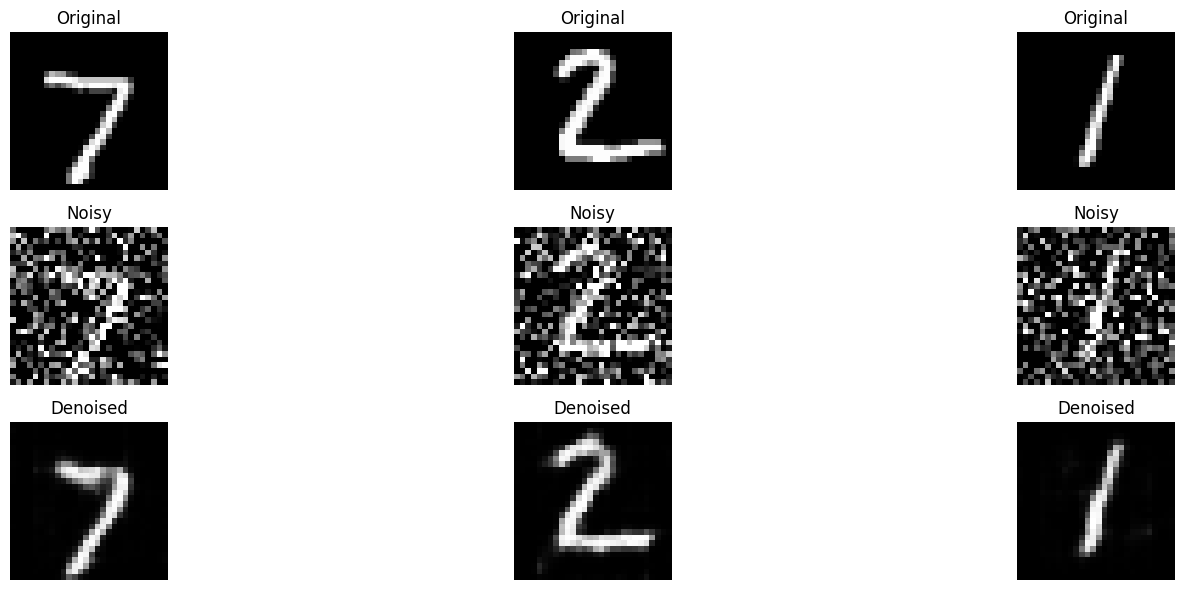

In [ ]:
train(model, train_loader, criterion, optimizer, epochs=5)
visualize_denoising(model, test_loader)